<a href="https://colab.research.google.com/github/ainan21/demo/blob/master/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install TensorFlow

In [ ]:
!pip install tensorflow

# Import Libraries

In [ ]:
!pip install tensorflow==2.14.0
import tensorflow as tf
print(tf.__version__)


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


# Mount Google Drive and Unzip the Dataset

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Locate zip file path
zip_path = "/content/drive/MyDrive/CNN Image Classification/cats_dogs_mini_dataset.zip"


In [ ]:
# Unzip file
import zipfile
import os

extract_path = "/content/cats_dogs"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")


Dataset unzipped successfully!


# Load all dataset images and normalize

In [ ]:
data_dir = "/content/cats_dogs"
categories = ["cats_set", "dogs_set"]

data = []
labels = []

for cat in categories:
    path = os.path.join(data_dir, cat)
    for img_file in os.listdir(path):
        img_path = os.path.join(path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (32, 32))  # resize for faster computation
        data.append(img)
        labels.append(0 if cat == "cats_set" else 1)

data = np.array(data)
labels = np.array(labels)

# Normalize pixel values (0–1)
data = data / 255.0

print("Dataset loaded successfully!")
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Dataset loaded successfully!
Data shape: (1000, 32, 32)
Labels shape: (1000,)


# Split dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [ ]:
# Reshape to add channel dimension
X_train = X_train.reshape(-1, 32, 32, 1)
X_test = X_test.reshape(-1, 32, 32, 1)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (800, 32, 32, 1)
Testing data shape: (200, 32, 32, 1)


# Build the CNN Model

In [ ]:
model = keras.Sequential([
    # First convolution + pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    layers.MaxPooling2D(2, 2),

    # Second convolution + pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Flatten layer converts 2D feature maps → 1D vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(64, activation='relu'),

    # Output layer → 1 neuron (0 or 1)
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5233 - loss: 0.6935 - val_accuracy: 0.5625 - val_loss: 0.6916
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6017 - loss: 0.6838 - val_accuracy: 0.5750 - val_loss: 0.6884
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5902 - loss: 0.6699 - val_accuracy: 0.5875 - val_loss: 0.6759
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.6864 - loss: 0.6387 - val_accuracy: 0.5625 - val_loss: 0.7104
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7085 - loss: 0.5892 - val_accuracy: 0.5688 - val_loss: 0.7342


In [ ]:
# Evaluate the Model on Test Data
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\n✅ Test Accuracy:", test_acc)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6252 - loss: 0.6672

✅ Test Accuracy: 0.5950000286102295


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


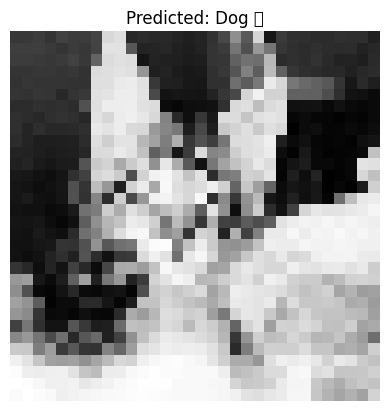

In [ ]:
#Make Predictions (Let’s test the model with a random image from the test set.)
import random

index = random.randint(0, len(X_test) - 1)
image = X_test[index]

plt.imshow(image.reshape(32, 32), cmap='gray')
plt.axis('off')

pred = model.predict(image.reshape(1, 32, 32, 1))
label = "Dog 🐶" if pred > 0.5 else "Cat 🐱"
plt.title("Predicted: " + label)
plt.show()
